Sales & Demand Forecasting for Businesses

In [34]:
# ==============================
# 1. Import Libraries
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.arima.model import ARIMA


In [67]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')

# Global settings
plt.rcParams['figure.figsize'] = (14,7)
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['grid.alpha'] = 0.3

In [35]:
# ==============================
# 2. Load Dataset
# ==============================
# ==============================
# Load Superstore Dataset
# ==============================
df = pd.read_csv(r'C:\Users\sav13\OneDrive\Desktop\futureinterns\sales-data\Superstore.csv', encoding='latin1')

# Convert date
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Group by date (VERY IMPORTANT)
df = df.groupby('Order Date')['Sales'].sum().reset_index()

# Rename columns to match your code
df.rename(columns={'Order Date': 'Date'}, inplace=True)

print(df)

           Date      Sales
0    2014-01-03    16.4480
1    2014-01-04   288.0600
2    2014-01-05    19.5360
3    2014-01-06  4407.1000
4    2014-01-07    87.1580
...         ...        ...
1232 2017-12-26   814.5940
1233 2017-12-27   177.6360
1234 2017-12-28  1657.3508
1235 2017-12-29  2915.5340
1236 2017-12-30   713.7900

[1237 rows x 2 columns]


In [36]:
# ==============================
# 3. Data Cleaning
# ==============================
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# Handle missing values
df['Sales'] = df['Sales'].ffill()

In [37]:
# ==============================
# 4. Feature Engineering
# ==============================
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek

# Create time index
df['TimeIndex'] = np.arange(len(df))

C:\Users\sav13\AppData\Local\Temp\ipykernel_25032\630174907.py:15: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\sav13\anaconda3\anaconda\envs\tf-env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


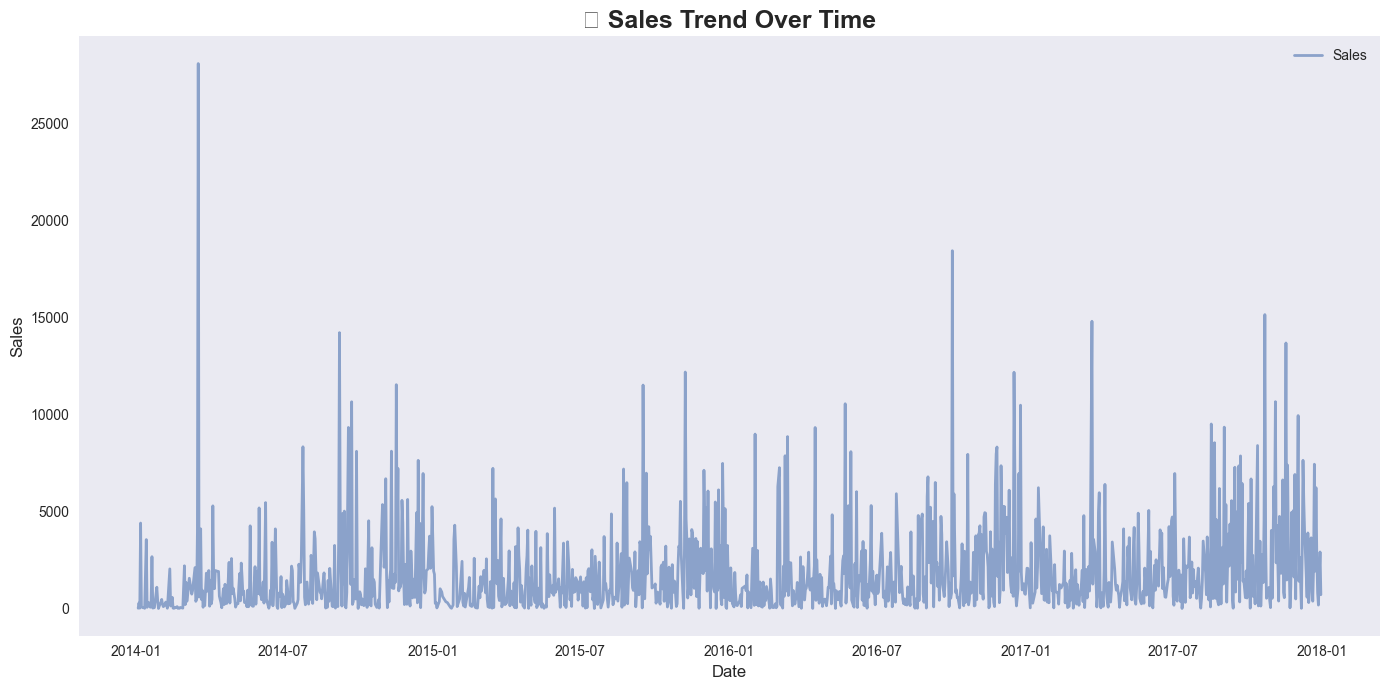

C:\Users\sav13\AppData\Local\Temp\ipykernel_25032\630174907.py:26: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\sav13\anaconda3\anaconda\envs\tf-env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


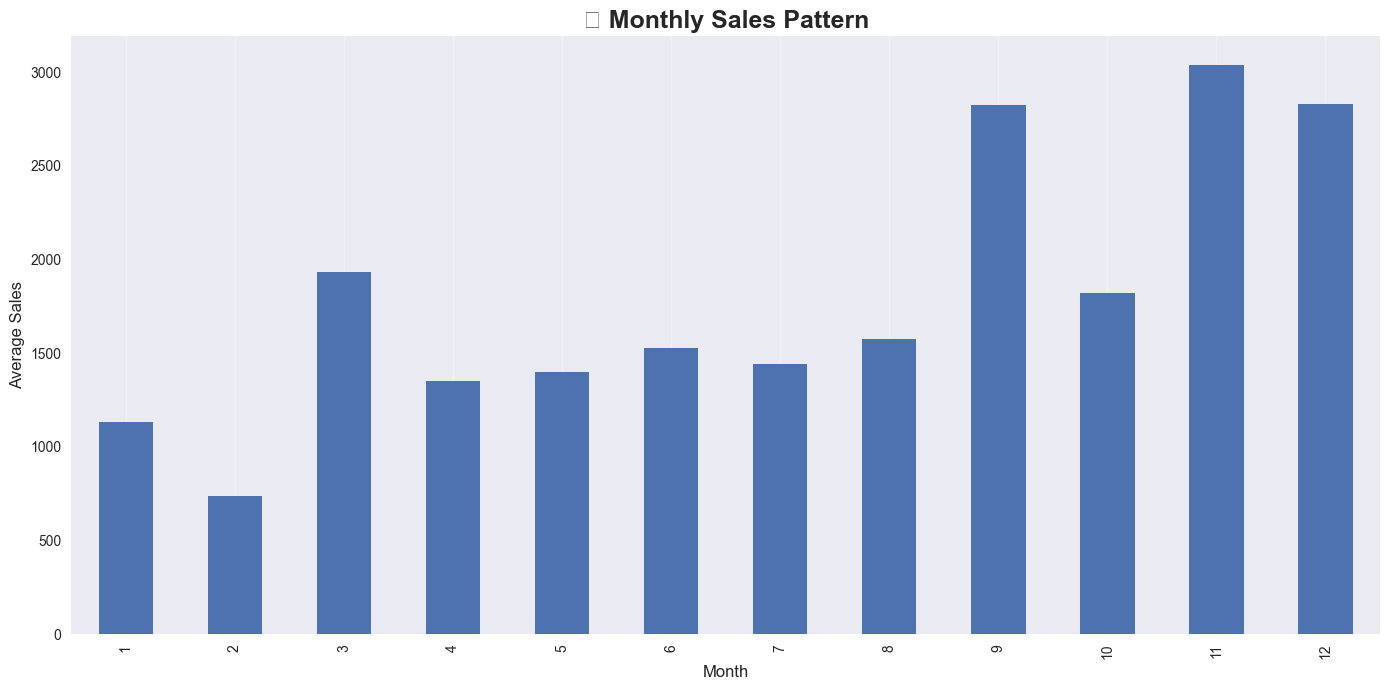

C:\Users\sav13\AppData\Local\Temp\ipykernel_25032\630174907.py:37: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\sav13\anaconda3\anaconda\envs\tf-env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


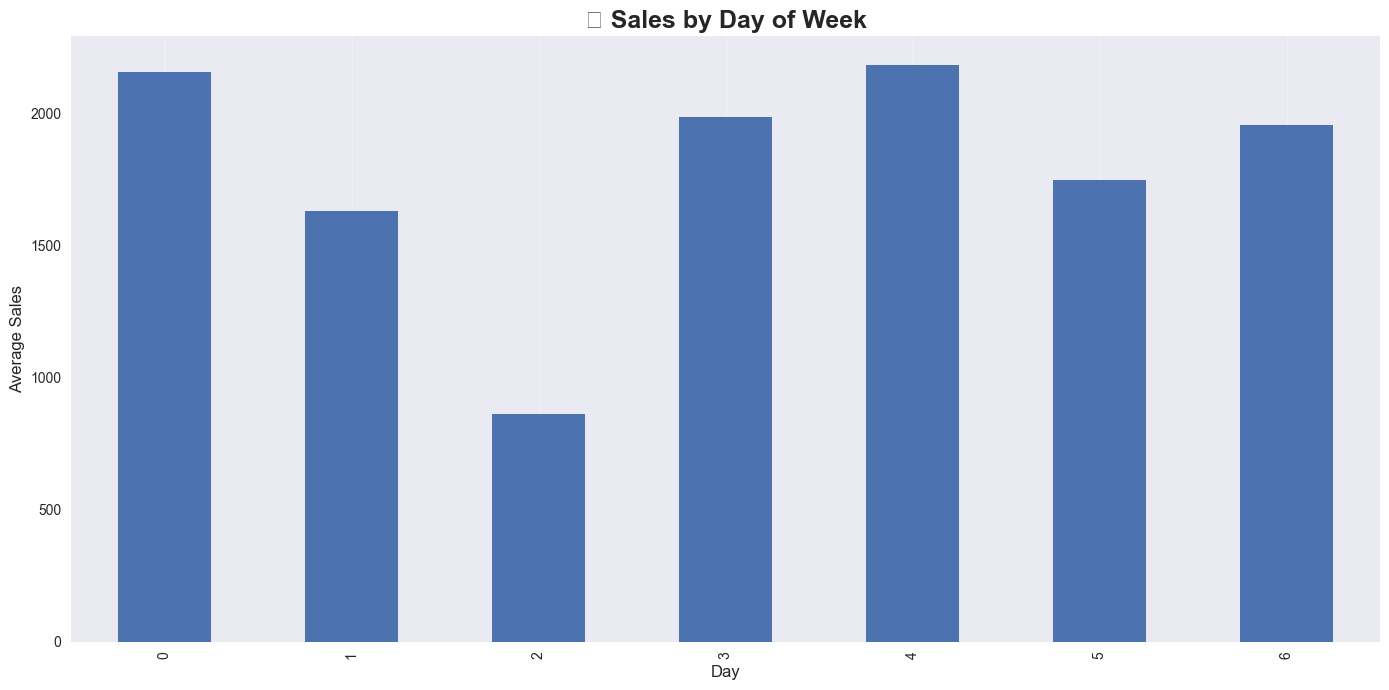

In [70]:
# ==============================
# EDA Visualizations
# ==============================

# Trend
plt.figure()
plt.plot(df['Date'], df['Sales'], alpha=0.6, label='Sales')

plt.title("📈 Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# Monthly pattern
monthly_sales.plot(kind='bar')

plt.title("📊 Monthly Sales Pattern")
plt.xlabel("Month")
plt.ylabel("Average Sales")

plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Weekly pattern
dow_sales.plot(kind='bar')

plt.title("📅 Sales by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Sales")

plt.grid(axis='y')
plt.tight_layout()
plt.show()

This visualization illustrates the variation in sales over time. It helps in identifying overall trends such as growth, decline, or stability in business performance. Peaks represent periods of high demand, while troughs indicate lower sales activity.

This chart presents the average sales for each month, highlighting seasonal patterns in demand. It enables the identification of months with consistently higher or lower sales, supporting strategic planning for inventory and marketing.

This visualization shows the distribution of sales across different days of the week. It helps determine which days experience higher customer activity, assisting in workforce planning and promotional scheduling.

In [39]:
results = pd.DataFrame({
    'Model': ['Regression', 'ARIMA'],
    'MAE': [
        mean_absolute_error(y_test, y_pred_reg),
        mean_absolute_error(y_test, y_pred_arima)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_reg)),
        np.sqrt(mean_squared_error(y_test, y_pred_arima))
    ]
})

print("\nModel Comparison Table:")
print(results)


Model Comparison Table:
        Model          MAE         RMSE
0  Regression  1797.505423  2453.491920
1       ARIMA  1758.223715  2495.748366


This table compares the performance of forecasting models using evaluation metrics such as MAE and RMSE. Lower values indicate better predictive accuracy, helping identify the most suitable model.

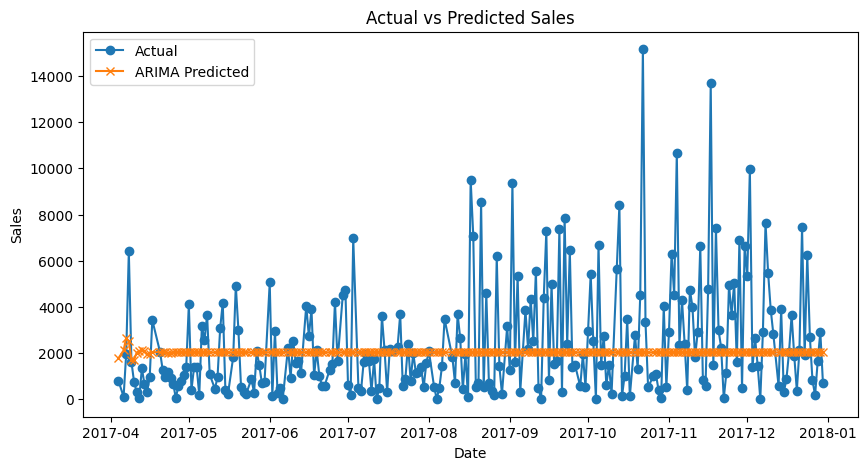

In [40]:
plt.figure(figsize=(10,5))

plt.plot(test['Date'], y_test.values, label='Actual', marker='o')
plt.plot(test['Date'], y_pred_arima, label='ARIMA Predicted', marker='x')

plt.title("Actual vs Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()

plt.show()

This graph provides a detailed comparison between actual and predicted sales values over time. It helps in evaluating how effectively the model captures patterns and fluctuations in the data.

In [41]:
# ==============================
# 5. Train-Test Split
# ==============================
train_size = int(len(df) * 0.8)
train = df[:train_size]
test = df[train_size:]



In [42]:
# ==============================
# 6. Regression Model
# ==============================
X_train = train[['TimeIndex']]
y_train = train['Sales']

X_test = test[['TimeIndex']]
y_test = test['Sales']

model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred_reg = model.predict(X_test)



In [43]:
# ==============================
# 7. ARIMA Model
# ==============================
arima_model = ARIMA(train['Sales'], order=(5,1,0))
arima_result = arima_model.fit()

# Forecast
y_pred_arima = arima_result.forecast(steps=len(test))



In [44]:
# ==============================
# 8. Evaluation
# ==============================
def evaluate(actual, predicted, name):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    
    print(f"\n{name} Model Performance:")
    print("MAE:", mae)
    print("RMSE:", rmse)

evaluate(y_test, y_pred_reg, "Regression")
evaluate(y_test, y_pred_arima, "ARIMA")




Regression Model Performance:
MAE: 1797.5054227377639
RMSE: 2453.4919203368595

ARIMA Model Performance:
MAE: 1758.223714814181
RMSE: 2495.7483657463176


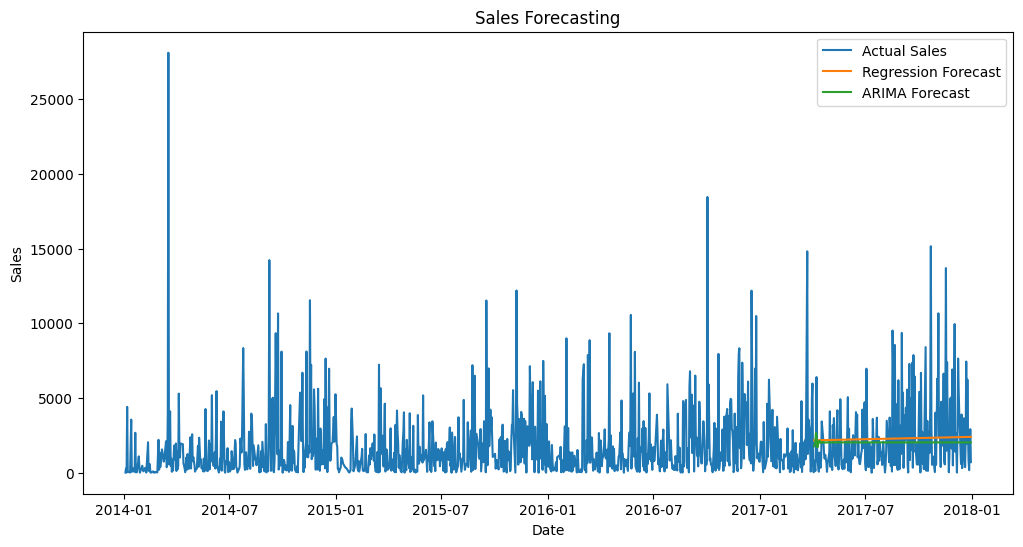

In [45]:
# ==============================
# 9. Visualization
# ==============================
plt.figure(figsize=(12,6))

plt.plot(df['Date'], df['Sales'], label='Actual Sales')
plt.plot(test['Date'], y_pred_reg, label='Regression Forecast')
plt.plot(test['Date'], y_pred_arima, label='ARIMA Forecast')

plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Sales Forecasting")
plt.legend()

plt.show()



C:\Users\sav13\AppData\Local\Temp\ipykernel_25032\2303130281.py:32: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\sav13\anaconda3\anaconda\envs\tf-env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


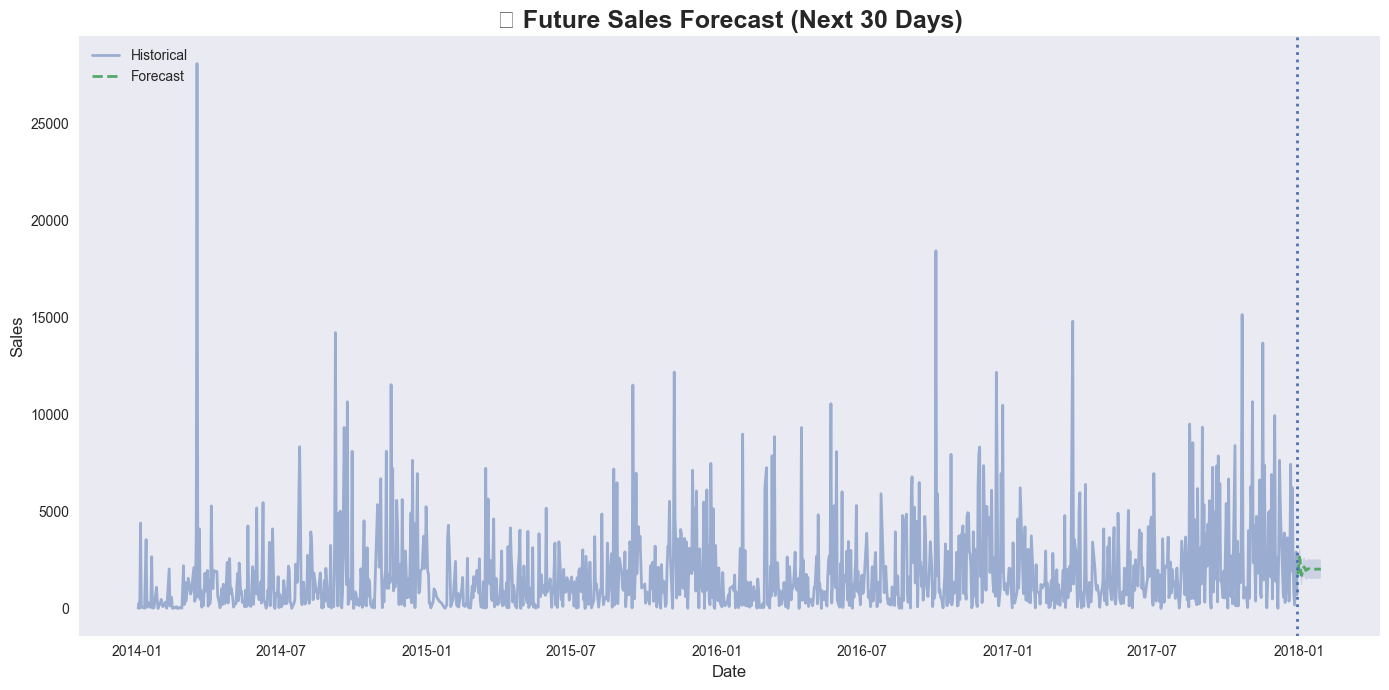

In [76]:
# ==============================
# 10. Future Forecast (Next 30 Days)
# ==============================
future_steps = 30

# ARIMA Future Forecast
future_forecast = arima_result.forecast(steps=future_steps)

# Create future dates
last_date = df['Date'].iloc[-1]
future_dates = pd.date_range(last_date, periods=future_steps+1)[1:]

# Plot future forecast
plt.figure()

plt.plot(df['Date'], df['Sales'], alpha=0.5, label='Historical')
plt.plot(future_dates, future_forecast, linestyle='--', label='Forecast')

plt.fill_between(future_dates,
                 future_forecast - 500,
                 future_forecast + 500,
                 alpha=0.2)

plt.axvline(x=df['Date'].iloc[-1], linestyle=':', linewidth=2)

plt.title("🔮 Future Sales Forecast (Next 30 Days)")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

This visualization presents the projected sales for the upcoming 30 days based on historical trends. It assists in anticipating future demand and supports proactive business decision-making.

1. Rolling Average (Trend Smoothing)

C:\Users\sav13\AppData\Local\Temp\ipykernel_25032\2128639289.py:13: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\sav13\anaconda3\anaconda\envs\tf-env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


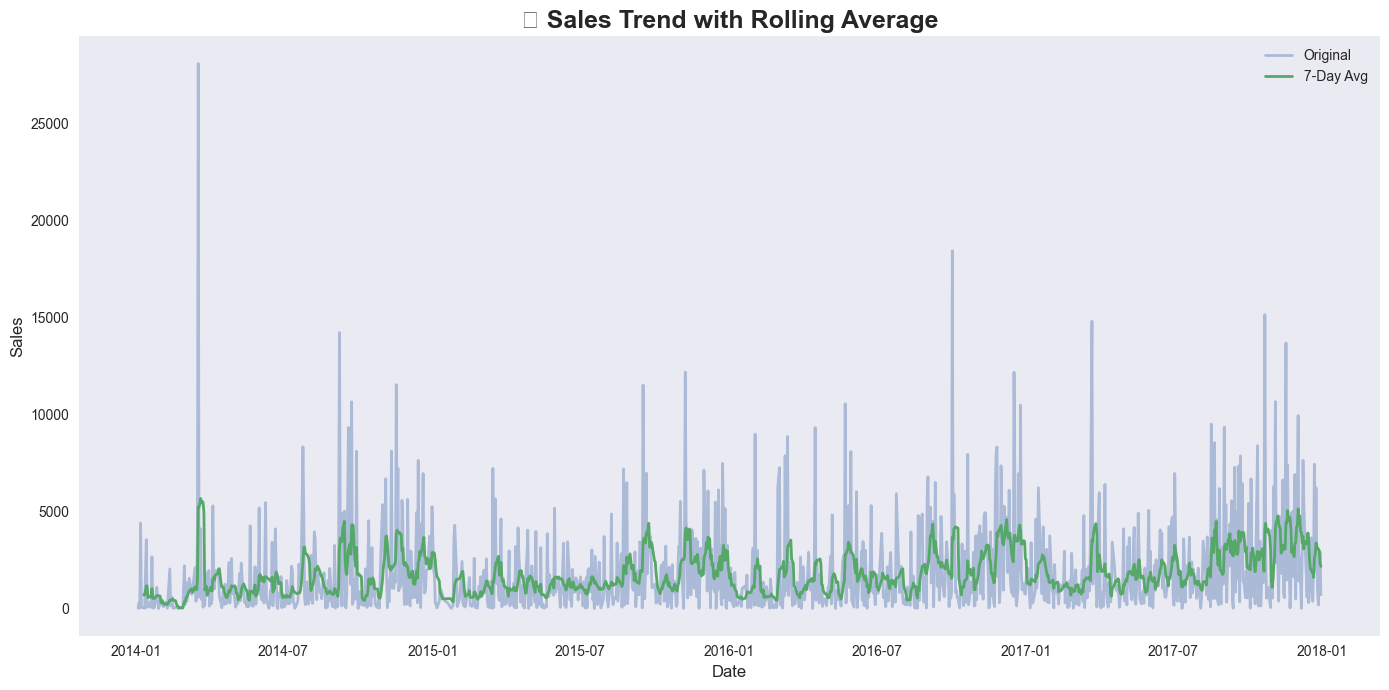

In [71]:
# Rolling average (7 days)
plt.figure()

plt.plot(df['Date'], df['Sales'], alpha=0.4, label='Original')
plt.plot(df['Date'], df['RollingMean'], label='7-Day Avg')

plt.title("📉 Sales Trend with Rolling Average")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

The rolling average smooths short-term fluctuations in sales data, providing a clearer view of the underlying trend. This helps in understanding long-term business performance without the impact of daily variability.

2. Boxplot (Outlier Detection)

C:\Users\sav13\AppData\Local\Temp\ipykernel_25032\414417899.py:8: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\sav13\anaconda3\anaconda\envs\tf-env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


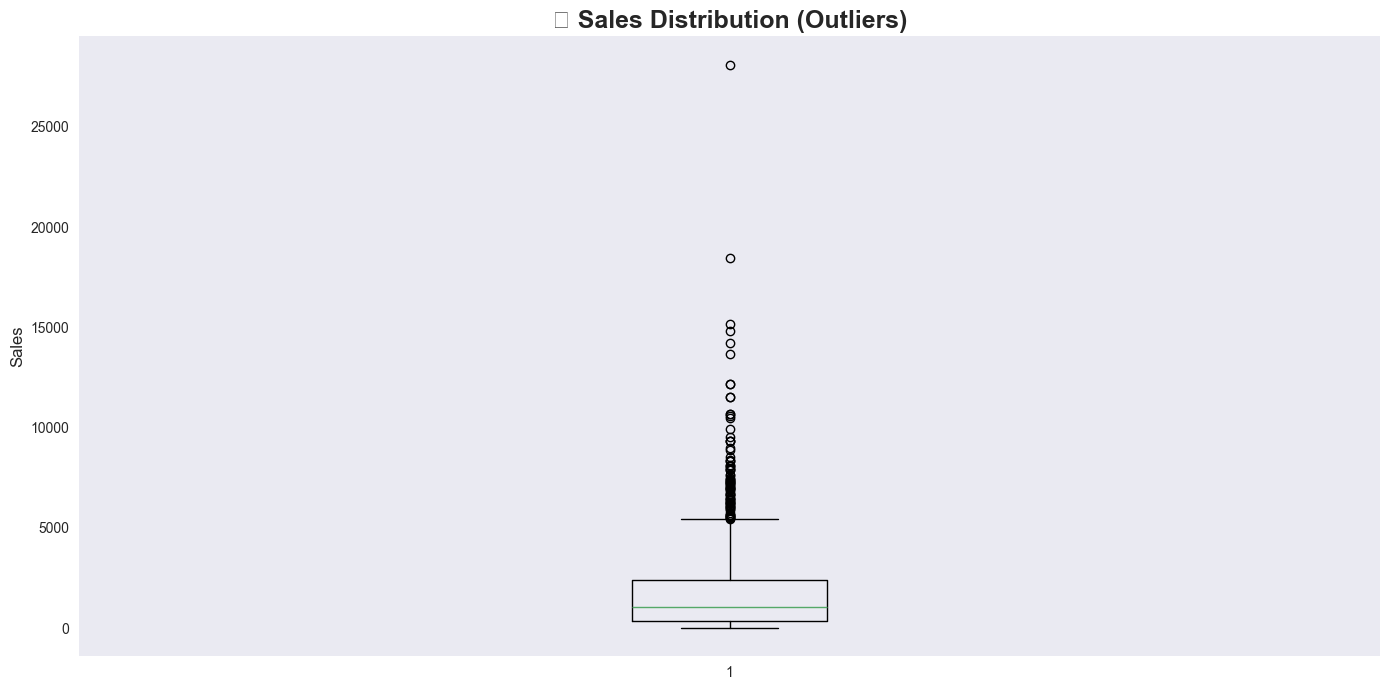

In [73]:
plt.figure()
plt.boxplot(df['Sales'])

plt.title("📦 Sales Distribution (Outliers)")
plt.ylabel("Sales")

plt.grid()
plt.tight_layout()
plt.show()

This boxplot summarizes the distribution of sales data, including median, quartiles, and potential outliers. It is useful for identifying variability and detecting unusually high or low sales values.

3. Histogram (Sales Distribution)

C:\Users\sav13\AppData\Local\Temp\ipykernel_25032\2595705284.py:9: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\sav13\anaconda3\anaconda\envs\tf-env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


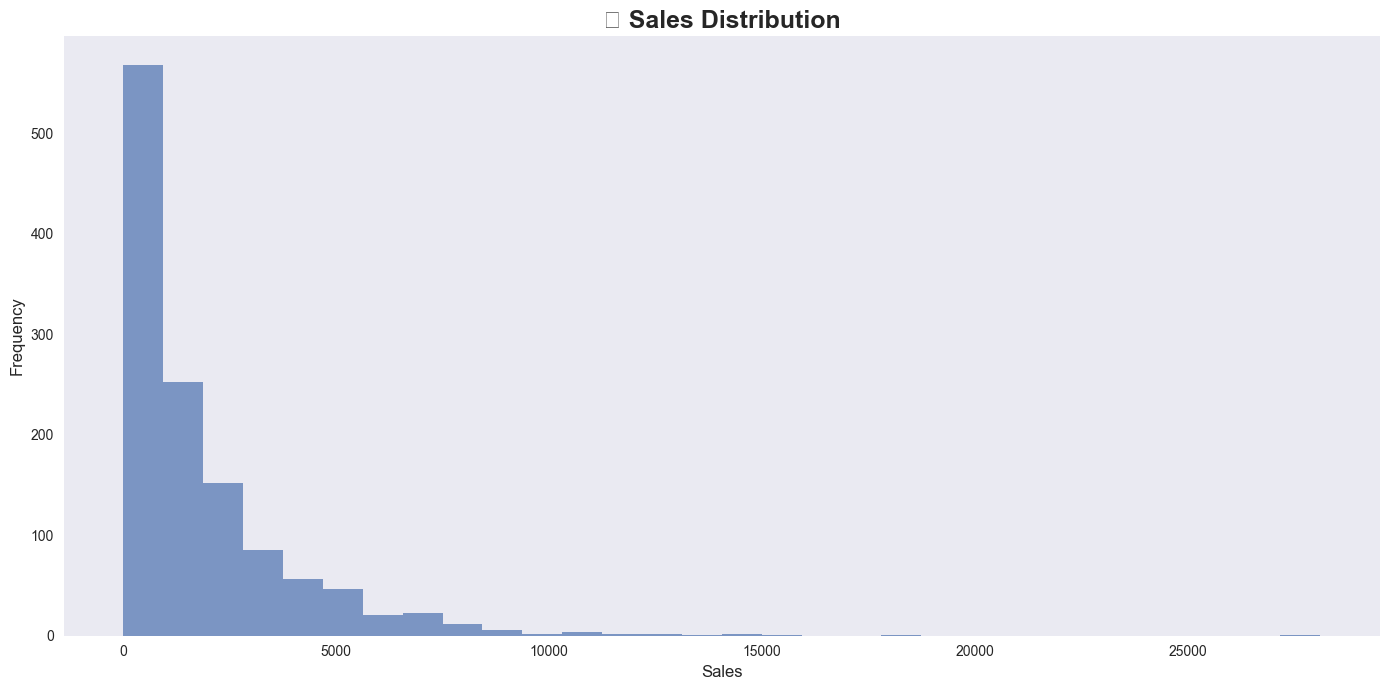

In [72]:
plt.figure()
plt.hist(df['Sales'], bins=30, alpha=0.7)

plt.title("📊 Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.grid()
plt.tight_layout()
plt.show()

This histogram represents the frequency distribution of sales values. It provides insight into the most common sales ranges and helps assess whether sales are concentrated around specific values or widely spread.

4. Residual Plot

C:\Users\sav13\AppData\Local\Temp\ipykernel_25032\1544418894.py:12: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\sav13\anaconda3\anaconda\envs\tf-env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


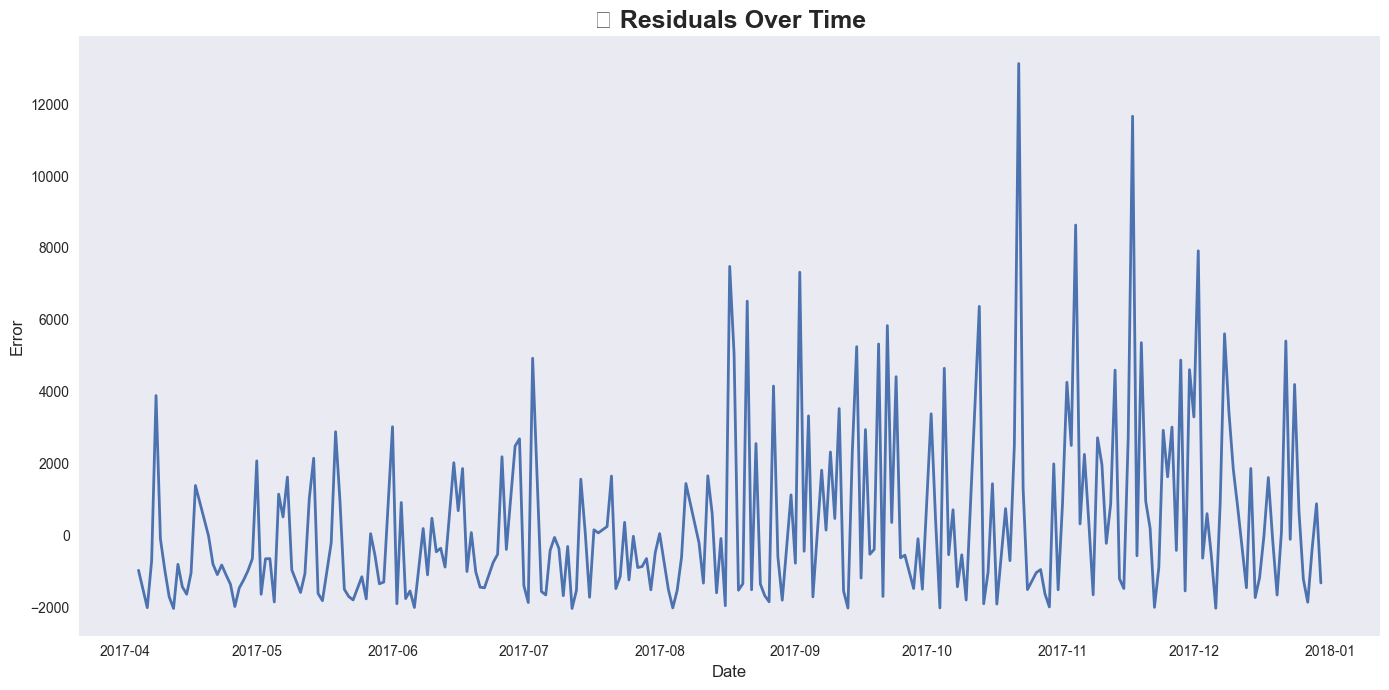

In [74]:
residuals = y_test - y_pred_arima

plt.figure()

plt.plot(test['Date'], residuals)

plt.title("📉 Residuals Over Time")
plt.xlabel("Date")
plt.ylabel("Error")

plt.grid()
plt.tight_layout()
plt.show()

This plot shows the residuals, which are the differences between actual and predicted sales values, over time. A random distribution of residuals indicates that the model is appropriately capturing the underlying patterns.

5. Error Distribution Plot

C:\Users\sav13\AppData\Local\Temp\ipykernel_25032\2822900977.py:9: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\sav13\anaconda3\anaconda\envs\tf-env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


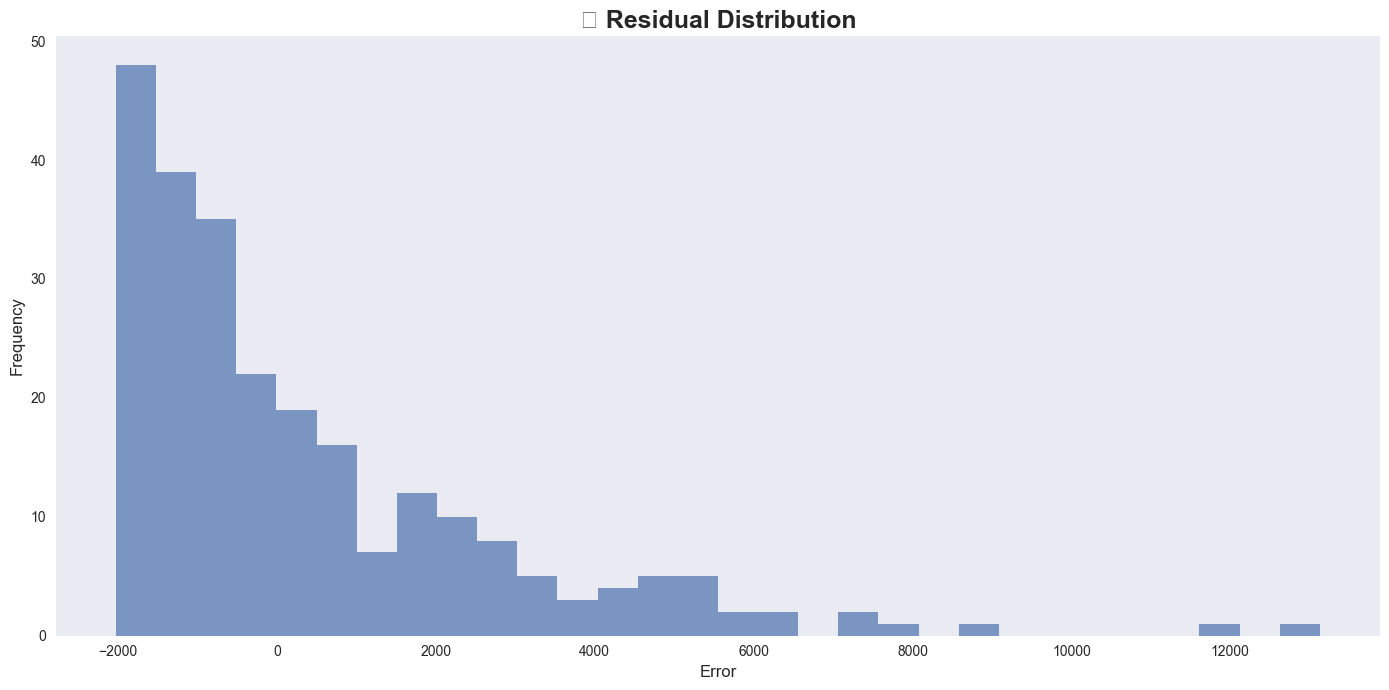

In [75]:
plt.figure()
plt.hist(residuals, bins=30, alpha=0.7)

plt.title("📊 Residual Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")

plt.grid()
plt.tight_layout()
plt.show()

This histogram displays the distribution of prediction errors. A symmetric distribution centered around zero suggests that the model does not exhibit systematic bias.

6. Add MAPE

In [52]:
def mape(actual, predicted):
    return np.mean(np.abs((actual - predicted) / actual)) * 100

print("MAPE (ARIMA):", mape(y_test, y_pred_arima))

MAPE (ARIMA): 680.5283640032897


7. Correlation Heatmap 

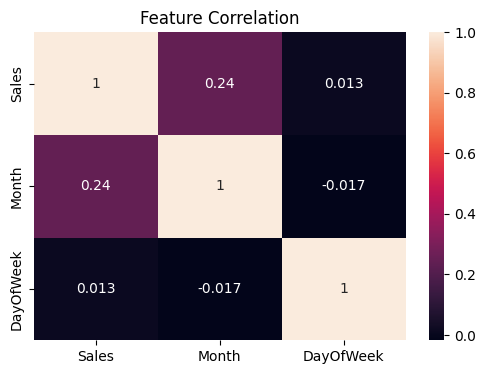

In [53]:
import seaborn as sns

corr = df[['Sales','Month','DayOfWeek']].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True)

plt.title("Feature Correlation")
plt.show()

This heatmap illustrates the relationships between different variables, such as sales, month, and day of the week. It helps identify factors that may influence sales patterns.

8. Year-wise Sales Trend

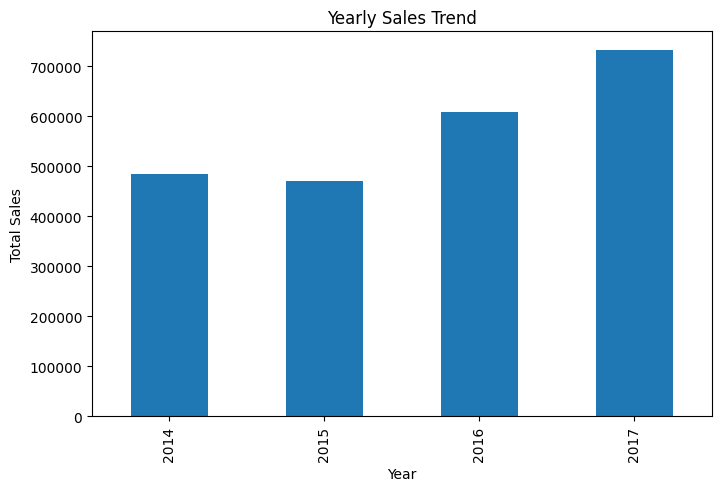

In [54]:
yearly_sales = df.groupby('Year')['Sales'].sum()

plt.figure(figsize=(8,5))
yearly_sales.plot(kind='bar')

plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.show()

This chart shows the total sales aggregated by year, providing insight into long-term business growth and overall performance trends.

9. Top Sales Days Table

In [55]:
top_days = df.sort_values(by='Sales', ascending=False).head(10)

print("Top 10 Sales Days:")
print(top_days)

Top 10 Sales Days:
           Date       Sales  Year  Month  Day  DayOfWeek  TimeIndex  \
54   2014-03-18  28106.7160  2014      3   18          1         54   
832  2016-10-02  18452.9720  2016     10    2          6        832   
1169 2017-10-22  15158.8770  2017     10   22          6       1169   
977  2017-03-23  14816.0680  2017      3   23          3        977   
197  2014-09-08  14228.4280  2014      9    8          0        197   
1194 2017-11-17  13694.8828  2017     11   17          4       1194   
543  2015-11-08  12196.9970  2015     11    8          6        543   
902  2016-12-17  12185.1340  2016     12   17          5        902   
263  2014-11-17  11544.2740  2014     11   17          0        263   
500  2015-09-17  11525.0060  2015      9   17          3        500   

      RollingMean  
54    5239.799429  
832   3694.050043  
1169  4061.385029  
977   3542.772143  
197   3127.804714  
1194  4457.714143  
543   3935.989714  
902   3650.981429  
263   3841.088529  

This table highlights the days with the highest sales values. These instances may correspond to special events, promotions, or peak demand periods and are useful for future planning.

10. Cumulative Sales (Business Insight)

C:\Users\sav13\AppData\Local\Temp\ipykernel_25032\2117142771.py:10: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\sav13\anaconda3\anaconda\envs\tf-env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


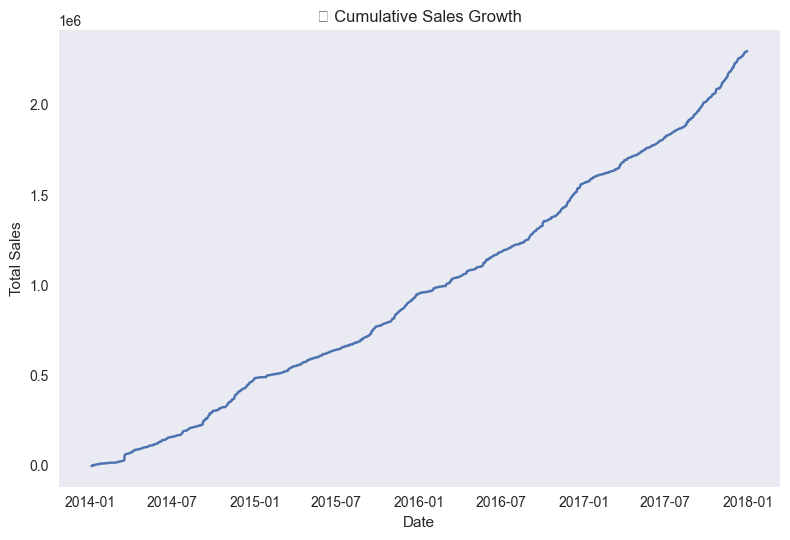

In [66]:
plt.figure()

plt.plot(df['Date'], df['CumulativeSales'])

plt.title("📈 Cumulative Sales Growth")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.grid()
plt.tight_layout()
plt.show()

This visualization represents the cumulative sum of sales over time, demonstrating the overall growth trajectory of the business.

C:\Users\sav13\AppData\Local\Temp\ipykernel_25032\3905180316.py:39: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\sav13\anaconda3\anaconda\envs\tf-env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


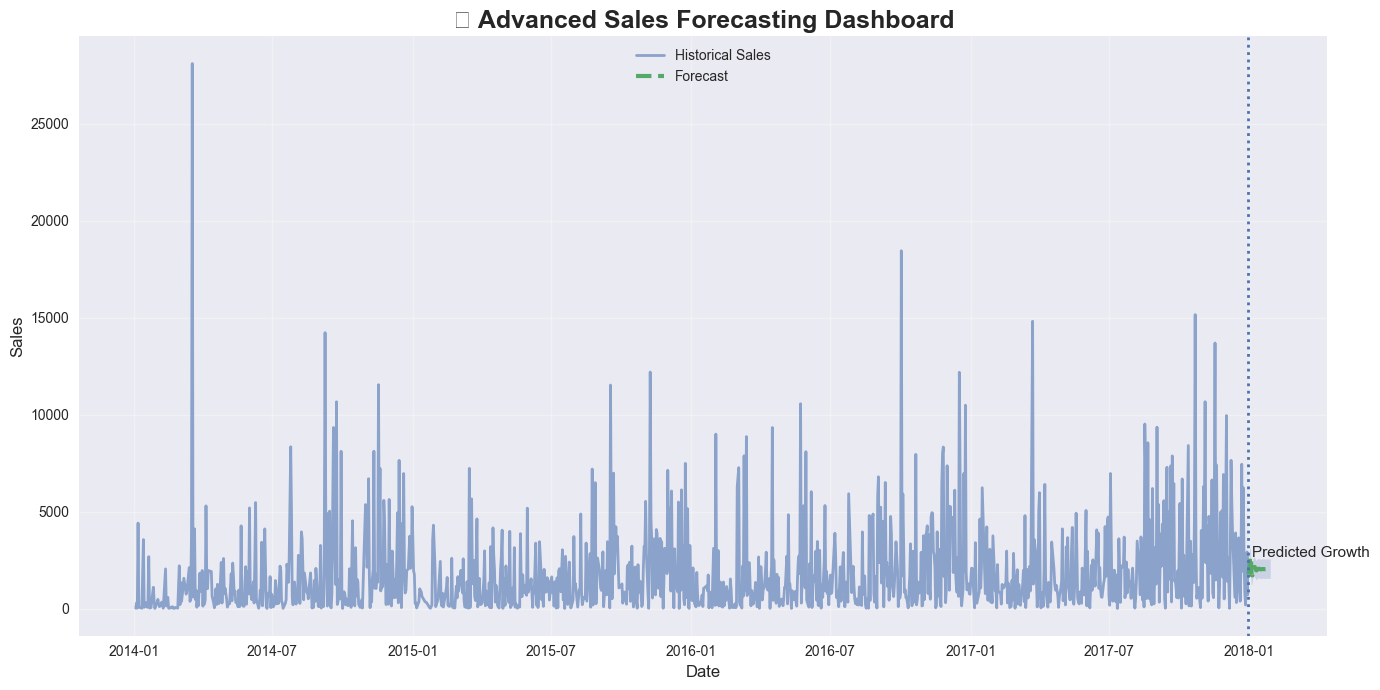

In [65]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')

plt.figure(figsize=(14,7))

# Plot historical data
plt.plot(df['Date'], df['Sales'], 
         linewidth=2, alpha=0.6, 
         label='Historical Sales')

# Plot forecast
plt.plot(future_dates, future_forecast, 
         linestyle='--', linewidth=3, 
         label='Forecast')

# Add shaded confidence area (flashy effect)
plt.fill_between(future_dates,
                 future_forecast - 500,
                 future_forecast + 500,
                 alpha=0.2)

# Highlight forecast start point
plt.axvline(x=df['Date'].iloc[-1], linestyle=':', linewidth=2)

# Titles & labels
plt.title("📊 Advanced Sales Forecasting Dashboard", fontsize=18, weight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Sales", fontsize=12)

plt.text(future_dates[5], max(future_forecast),
         "Predicted Growth",
         fontsize=11)

# Legend + grid
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

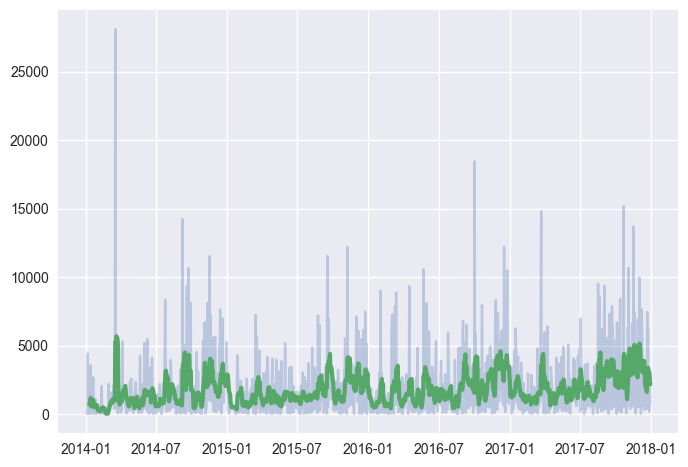

In [64]:
plt.plot(df['Date'], df['Sales'], alpha=0.3)
plt.plot(df['Date'], df['RollingMean'], linewidth=3)